In [40]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats


# ROOT = Path(__file__).resolve().parents[1]
# REPO = ROOT.parents[2]
# DATA_PATH = REPO / "archive" / "raw" / "secom.csv"
# OUT = ROOT / "outputs"
# OUT.mkdir(exist_ok=True)

VARIABLE = "x297"
# ALPHA = 0.005
# N_PERM = 399
RNG = np.random.default_rng(611211106)


def load_series():
    df = pd.read_csv(r'C:\Users\No\Documents\GitHub\WHAT_I_DID\archive\raw\secom.csv', sep="\t", parse_dates=["Time"])
    raw = df[["Time", VARIABLE, "Pass/Fail"]].copy()
    raw = raw.rename(columns={VARIABLE: "x"})
    raw = raw.sort_values("Time").reset_index(drop=True)
    raw["t"] = np.arange(1, len(raw) + 1)

    n_raw = len(raw)
    m_raw = n_raw // 2
    phase_i_raw = raw.iloc[:m_raw].copy()
    phase_ii_raw = raw.iloc[m_raw:].copy()

    phase_i_no_missing = phase_i_raw.dropna(subset=["x"]).copy()
    q1, q3 = phase_i_no_missing["x"].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 3.0 * iqr
    upper = q3 + 3.0 * iqr
    phase_i_clean = phase_i_no_missing[
        (phase_i_no_missing["x"] >= lower) & (phase_i_no_missing["x"] <= upper)
    ].copy()
    phase_ii_observed = phase_ii_raw.dropna(subset=["x"]).copy()

    summary = {
        "variable": VARIABLE,
        "raw_n": n_raw,
        "raw_phase_i_n": int(len(phase_i_raw)),
        "raw_phase_ii_n": int(len(phase_ii_raw)),
        "phase_i_missing_removed": int(phase_i_raw["x"].isna().sum()),
        "phase_ii_missing_count_not_preprocessed": int(phase_ii_raw["x"].isna().sum()),
        "outlier_rule": "Phase I only: 3 IQR filter after dropping Phase I missing values",
        "phase_i_outlier_lower": float(lower),
        "phase_i_outlier_upper": float(upper),
        "phase_i_outliers_removed": int(len(phase_i_no_missing) - len(phase_i_clean)),
        "phase_i_clean_n": int(len(phase_i_clean)),
        "phase_ii_observed_n_for_diagnostics": int(len(phase_ii_observed)),
        "phase_i_mean": float(phase_i_clean["x"].mean()),
        "phase_i_std": float(phase_i_clean["x"].std(ddof=1)),
        "phase_i_min": float(phase_i_clean["x"].min()),
        "phase_i_q1": float(phase_i_clean["x"].quantile(0.25)),
        "phase_i_median": float(phase_i_clean["x"].median()),
        "phase_i_q3": float(phase_i_clean["x"].quantile(0.75)),
        "phase_i_max": float(phase_i_clean["x"].max()),
        "phase_ii_raw_mean": float(phase_ii_observed["x"].mean()),
        "phase_ii_raw_std": float(phase_ii_observed["x"].std(ddof=1)),
        "phase_ii_raw_min": float(phase_ii_observed["x"].min()),
        "phase_ii_raw_max": float(phase_ii_observed["x"].max()),
    }
    return raw, phase_i_clean, phase_ii_raw, phase_ii_observed, summary

In [11]:
raw, phase_i_clean, phase_ii_raw, phase_ii_observed, summary = load_series()


In [12]:
print(phase_ii_observed["x"].agg([
    "mean",
    "std",
    "min",
    lambda s: s.quantile(0.25),
    "median",
    lambda s: s.quantile(0.75),
    "max"
]))

mean         1900.079969
std          1986.931471
min            50.911700
<lambda>      591.493650
median       1189.963500
<lambda>     2433.785375
max         15559.952500
Name: x, dtype: float64


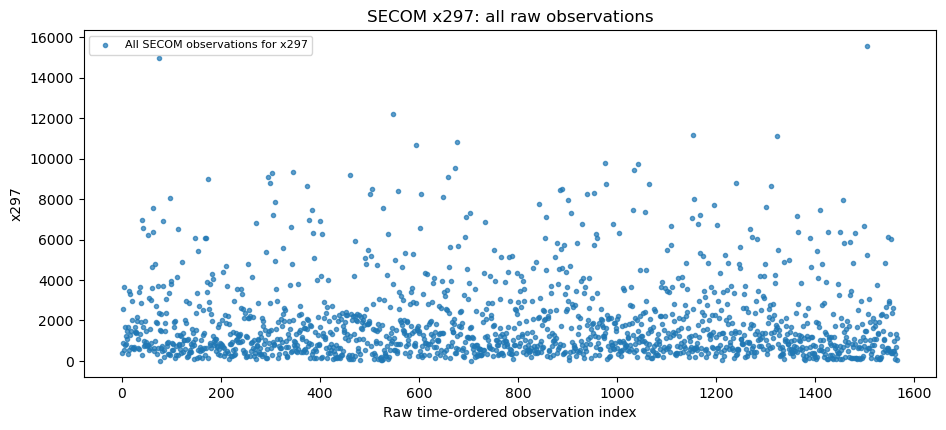

In [16]:
fig, ax = plt.subplots(figsize=(11, 4.5))

ax.scatter(
    raw["t"],
    raw["x"],
    s=9,
    alpha=0.7,
    label=f"All SECOM observations for {VARIABLE}",
)

ax.set_title(f"SECOM {VARIABLE}: all raw observations")
ax.set_xlabel("Raw time-ordered observation index")
ax.set_ylabel(VARIABLE)
ax.legend(loc="best", fontsize=8)

plt.show()

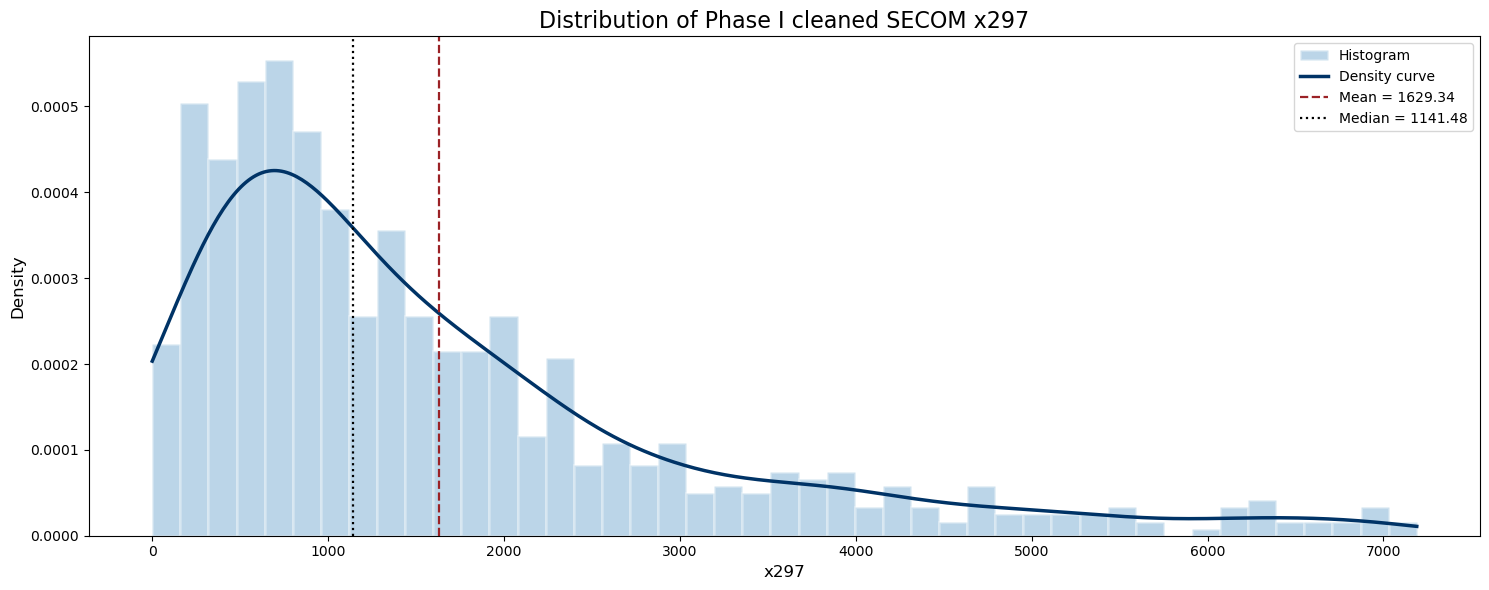

In [28]:

x_phase_i = phase_i_clean["x"].dropna()

mean_x = x_phase_i.mean()
median_x = x_phase_i.median()

fig, ax = plt.subplots(figsize=(15, 6))

ax.hist(
    x_phase_i,
    bins=45,
    density=True,
    alpha=0.3,
    edgecolor="white",
    linewidth=2,
    label="Histogram",
)

kde = stats.gaussian_kde(x_phase_i)
x_grid = np.linspace(x_phase_i.min(), x_phase_i.max(), 500)

ax.plot(
    x_grid,
    kde(x_grid),
    color="#003366",
    lw=2.5,
    label="Density curve",
)


ax.axvline(
    mean_x,
    color="#9b2226",
    linestyle="--",
    lw=1.6,
    label=f"Mean = {mean_x:.2f}",
)

ax.axvline(
    median_x,
    color="black",
    linestyle=":",
    lw=1.6,
    label=f"Median = {median_x:.2f}",
)

ax.set_title(f"Distribution of Phase I cleaned SECOM {VARIABLE}", fontsize=16)
ax.set_xlabel(VARIABLE, fontsize=12)
ax.set_ylabel("Density", fontsize=12)

ax.legend(loc="upper right", fontsize=10)
fig.tight_layout()

plt.show()

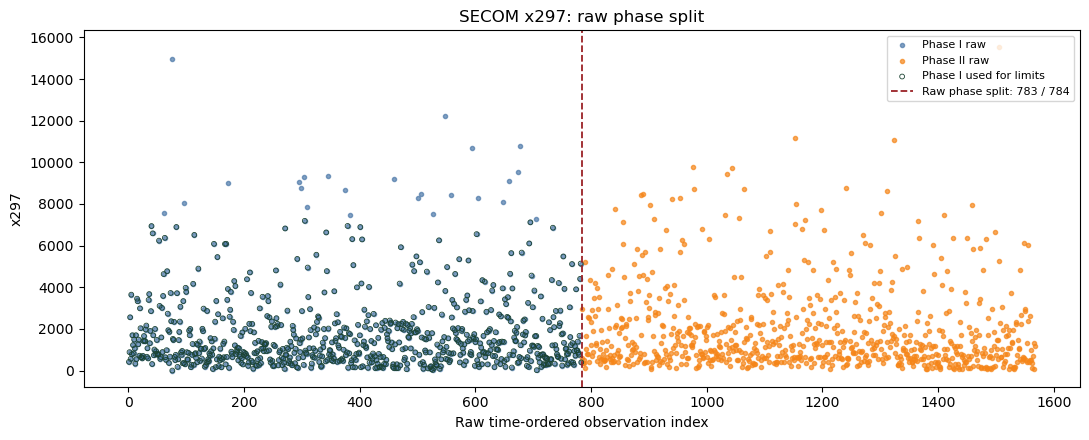

In [24]:
raw, phase_i_clean, phase_ii_raw, phase_ii_observed, summary = load_series()

m_raw = len(raw) // 2
phase_i_raw = raw.iloc[:m_raw]
phase_ii_raw = raw.iloc[m_raw:]

fig, ax = plt.subplots(figsize=(11, 4.5))

ax.scatter(
    phase_i_raw["t"],
    phase_i_raw["x"],
    s=9,
    color="#4c78a8",
    alpha=0.7,
    label="Phase I raw",
)

ax.scatter(
    phase_ii_raw["t"],
    phase_ii_raw["x"],
    s=9,
    color="#f58518",
    alpha=0.7,
    label="Phase II raw",
)

ax.scatter(
    phase_i_clean["t"],
    phase_i_clean["x"],
    s=12,
    facecolors="none",
    edgecolors="#1b4332",
    linewidths=0.6,
    label="Phase I used for limits",
)

ax.axvline(
    m_raw + 0.5,
    color="#9b2226",
    ls="--",
    lw=1.3,
    label=f"Raw phase split: {m_raw} / {m_raw + 1}",
)

ax.set_title(f"SECOM {VARIABLE}: raw phase split")
ax.set_xlabel("Raw time-ordered observation index")
ax.set_ylabel(VARIABLE)
ax.legend(loc="best", fontsize=8)

fig.tight_layout()
plt.show()

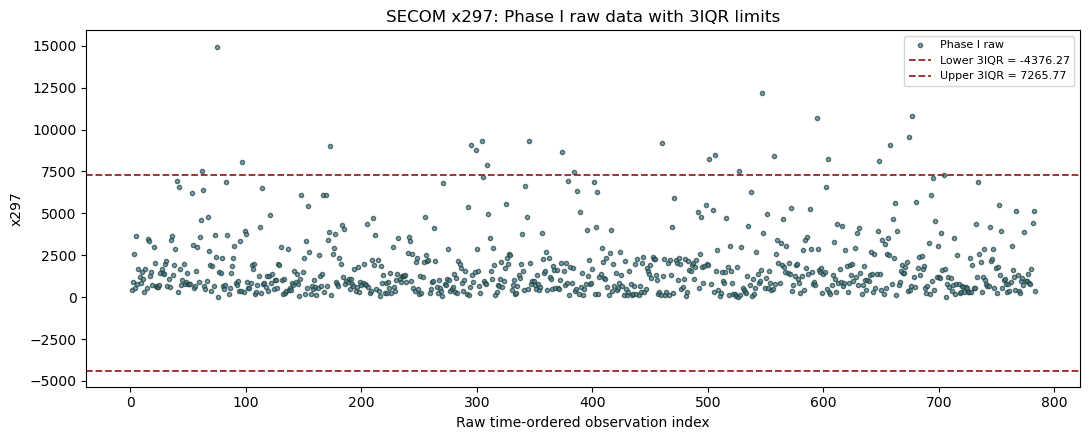

In [30]:
raw, phase_i_clean, phase_ii_raw, phase_ii_observed, summary = load_series()

m_raw = len(raw) // 2
phase_i_raw = raw.iloc[:m_raw].copy()

phase_i_no_missing = phase_i_raw.dropna(subset=["x"]).copy()

q1 = phase_i_no_missing["x"].quantile(0.25)
q3 = phase_i_no_missing["x"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 3.0 * iqr
upper = q3 + 3.0 * iqr

fig, ax = plt.subplots(figsize=(11, 4.5))

ax.scatter(
    phase_i_raw["t"],
    phase_i_raw["x"],
    s=9,
    color="#4c78a8",
    edgecolors="#1b4332",
    alpha=0.7,
    label="Phase I raw",
)

ax.axhline(
    lower,
    color="#9b2226",
    ls="--",
    lw=1.3,
    label=f"Lower 3IQR = {lower:.2f}",
)

ax.axhline(
    upper,
    color="#9b2226",
    ls="--",
    lw=1.3,
    label=f"Upper 3IQR = {upper:.2f}",
)

ax.set_title(f"SECOM {VARIABLE}: Phase I raw data with 3IQR limits")
ax.set_xlabel("Raw time-ordered observation index")
ax.set_ylabel(VARIABLE)
ax.legend(loc="best", fontsize=8)

fig.tight_layout()
plt.show()

In [ ]:
def max_segment_stat(x, mode):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < 12:
        return 0.0, 0
    cuts = np.arange(6, n - 5)
    csum = np.cumsum(x)
    csum2 = np.cumsum(x * x)
    total = csum[-1]
    total2 = csum2[-1]

    left_n = cuts
    right_n = n - cuts
    left_sum = csum[cuts - 1]
    right_sum = total - left_sum
    left_mean = left_sum / left_n
    right_mean = right_sum / right_n

    left_sse = csum2[cuts - 1] - (left_sum * left_sum / left_n)
    right_sse = (total2 - csum2[cuts - 1]) - (right_sum * right_sum / right_n)
    left_var = left_sse / (left_n - 1)
    right_var = right_sse / (right_n - 1)

    if mode == "level":
        scale = np.sqrt(left_var / left_n + right_var / right_n)
        vals = np.divide(
            np.abs(left_mean - right_mean),
            scale,
            out=np.zeros_like(scale),
            where=scale > 0,
        )
    else:
        var_min = np.minimum(left_var, right_var)
        var_max = np.maximum(left_var, right_var)
        vals = np.divide(var_max, var_min, out=np.zeros_like(var_max), where=var_min > 0)

    best_idx = int(np.argmax(vals))
    return float(vals[best_idx]), int(cuts[best_idx])


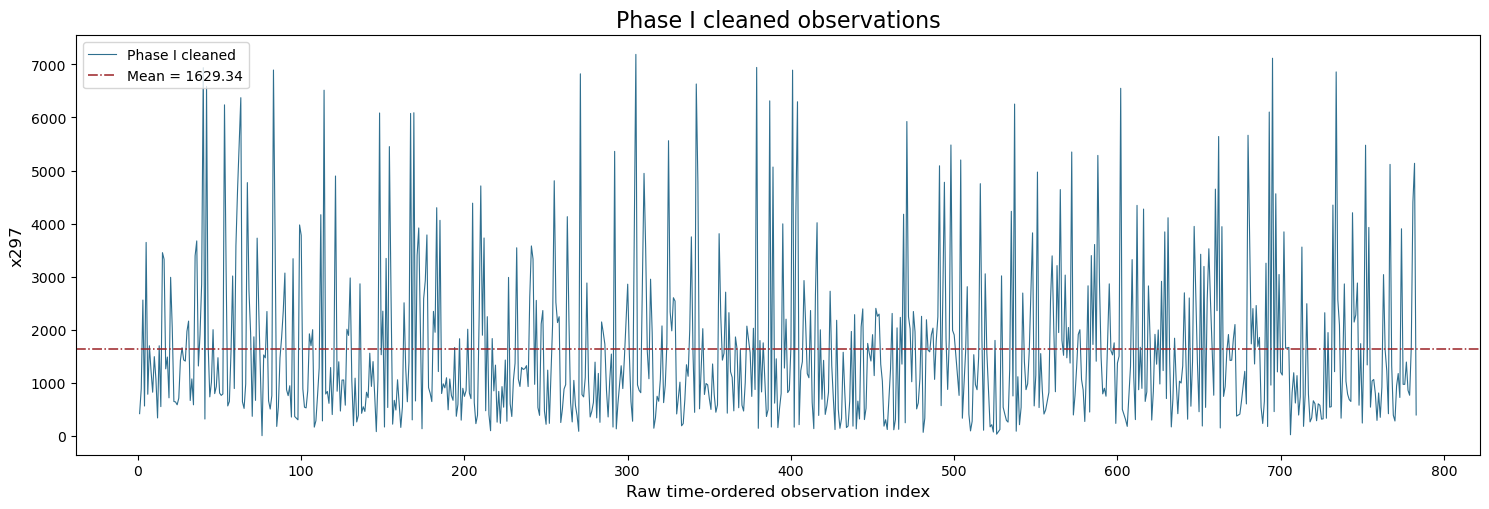

In [44]:
raw, phase_i_clean, phase_ii_raw, phase_ii_observed, summary = load_series()

fig, ax = plt.subplots(figsize=(15, 5.2))

ax.plot(
    phase_i_clean["t"],
    phase_i_clean["x"],
    color="#2f6f8f",
    lw=0.8,
    label="Phase I cleaned",
)

ax.axhline(
    phase_i_clean["x"].mean(),
    color="#9b2226",
    ls="-.",
    lw=1.1,
    label=f"Mean = {phase_i_clean['x'].mean():.2f}",
)

ax.set_title(
    f"Phase I cleaned observations",
    fontsize=16,
)

ax.set_xlabel("Raw time-ordered observation index", fontsize=12)
ax.set_ylabel(VARIABLE, fontsize=12)

ax.legend(loc="upper left", fontsize=10)
fig.tight_layout()

plt.show()